Diabetes Readmission Prediction with XAI

This notebook contains the complete machine learning pipeline from raw data
acquisition through model evaluation and explainability analysis.

**Pipeline steps:**
1. Data Acquisition — download UCI Diabetes 130-US dataset
2. Preprocessing — cohort selection, target binarization, imputation, encoding
3. Model Training — Logistic Regression, Decision Tree, Random Forest, XGBoost
4. SHAP Explanations — global feature attributions
5. LIME Explanations — local per-patient explanations
6. DiCE Counterfactuals — actionable recourse scenarios
7. Clinical Faithfulness — XAI vs ground-truth model mechanics
8. Statistical Validation — DeLong tests + bootstrap CIs
9. Explanation Stability — SHAP-LIME cross-method agreement
10. Figure Generation — ROC curves, top-10 SHAP, LIME patients, DiCE dual-pane

In [2]:
import os
import sys
import hashlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score, brier_score_loss, roc_curve,
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import shap
import lime
import lime.lime_tabular
import dice_ml
from scipy.stats import spearmanr
from MLstatkit import Delong_test, Bootstrapping
from ucimlrepo import fetch_ucirepo

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 14})
%matplotlib inline

print('All libraries imported successfully.')

All libraries imported successfully.


In [65]:
PROJECT_ROOT = Path('..')
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODEL_DIR = PROJECT_ROOT / 'models'
RESULTS_FIG = PROJECT_ROOT / 'results' / 'figures'
RESULTS_TBL = PROJECT_ROOT / 'results' / 'tables'

for d in [DATA_RAW, DATA_PROCESSED, MODEL_DIR, RESULTS_FIG, RESULTS_TBL]:
    d.mkdir(parents=True, exist_ok=True)


## Step 1: Data Acquisition

Download the Diabetes 130-US Hospitals dataset from the UCI Machine Learning
Repository (ID 296). The dataset contains 101,766 hospital encounters with
49 clinical features and a readmission target.

In [66]:
print('Fetching Diabetes 130-US hospitals dataset from UCI (ID: 296)...')
try:
    diabetes = fetch_ucirepo(id=296)
except Exception as e:
    print(f'Error fetching data: {e}')
    raise

df_raw = pd.concat([diabetes.data.ids, diabetes.data.features, diabetes.data.targets], axis=1)

expected_rows, expected_cols = 101766, 50
print(f'\nVerification Gate')
print(f'Actual Shape:   {df_raw.shape}')
print(f'Expected Shape: ({expected_rows}, {expected_cols})')
if df_raw.shape[0] == expected_rows and df_raw.shape[1] == expected_cols:
    print('Status: PASSED (Dimensions match perfectly).')
else:
    print('Status: FAILED (Dimensions do not match!).')

raw_path = DATA_RAW / 'diabetes_130_us_raw.csv'
df_raw.to_csv(raw_path, index=False)

print(f'\nSaved to: {raw_path}')
print(f'Exists: {raw_path.exists()}')

with open(raw_path, 'rb') as f:
    sha = hashlib.sha256(f.read()).hexdigest()
print(f'SHA256: {sha}')

Fetching Diabetes 130-US hospitals dataset from UCI (ID: 296)...

Verification Gate
Actual Shape:   (101766, 50)
Expected Shape: (101766, 50)
Status: PASSED (Dimensions match perfectly).

Saved to: ../data/raw/diabetes_130_us_raw.csv
Exists: True
SHA256: 0ee4c49545f267b7817954b90f7f81dd2cca20c352a2ff547ff859d2ad6a4aa6


## Step 2: Preprocessing & Feature Engineering

Clean the dataset, apply cohort selection (Strack et al. broad diabetes criteria),
binarize the target, deduplicate, handle missing values, group ICD-9 codes,
split into train/test, and encode features.

In [5]:
df = pd.read_csv(DATA_RAW / 'diabetes_130_us_raw.csv', low_memory=False, na_values=['?'])
print(f'Loaded raw data: {df.shape}')

Loaded raw data: (101766, 50)


In [6]:
# Broad diabetes inclusion: ICD-9 250.xx in any diag, OR diabetesMed, OR A1Cresult
def has_diabetes_icd9(val):
    if pd.isna(val): return False
    try: return np.floor(float(val)) == 250
    except (ValueError, TypeError): return False

diag_diabetes = (df['diag_1'].apply(has_diabetes_icd9) |
                 df['diag_2'].apply(has_diabetes_icd9) |
                 df['diag_3'].apply(has_diabetes_icd9))
med_diabetes = df['diabetesMed'] == 'Yes'
a1c_diabetes = df['A1Cresult'].notna() & (df['A1Cresult'] != 'None')

before = len(df)
df = df[diag_diabetes | med_diabetes | a1c_diabetes].copy()
print(f'After broad diabetes inclusion: {df.shape} (dropped {before - len(df)})')

# Exclude expired/hospice
expired_hospice_ids = [11, 13, 14, 19, 20, 21]
before = len(df)
df = df[~df['discharge_disposition_id'].isin(expired_hospice_ids)].copy()
print(f'After expired/hospice exclusion: {df.shape} (dropped {before - len(df)})')

# Exclude >50% missing critical attributes
critical_cols = ['race', 'gender', 'age', 'admission_type_id',
                 'discharge_disposition_id', 'admission_source_id',
                 'time_in_hospital', 'diag_1', 'diag_2', 'diag_3']
before = len(df)
df = df.dropna(subset=critical_cols, thresh=int(np.ceil(len(critical_cols) * 0.5))).copy()
print(f'After >50% critical-missing exclusion: {df.shape} (dropped {before - len(df)})')

After broad diabetes inclusion: (87604, 50) (dropped 14162)
After expired/hospice exclusion: (85811, 50) (dropped 1793)
After >50% critical-missing exclusion: (85811, 50) (dropped 0)


In [7]:
# Target binarization: <30 readmission = 1, else 0
df['readmitted'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# Deduplication: keep first encounter per patient
df = df.sort_values('encounter_id').drop_duplicates(subset=['patient_nbr'], keep='first')

print(f'After deduplication: {df.shape}')
print(f'Prevalence: {df["readmitted"].mean():.4f}')

After deduplication: (61553, 50)
Prevalence: 0.0936


In [8]:
# Drop weight (>96% missing)
if 'weight' in df.columns:
    df = df.drop(columns=['weight'])

# Fill missing categoricals
for col in ['medical_specialty', 'payer_code', 'race']:
    df[col] = df[col].fillna('Unknown')

# Lab results: fill NaN with 'None' (not tested)
for col in ['max_glu_serum', 'A1Cresult']:
    if col in df.columns:
        df[col] = df[col].fillna('None')

# Drop invalid gender
df = df[df['gender'] != 'Unknown/Invalid']

print(f'After missing data cleanup: {df.shape}')

After missing data cleanup: (61551, 49)


In [9]:
# ICD-9 grouping into 9 clinical categories
def map_icd9(val):
    if pd.isna(val): return 'Missing'
    if str(val).startswith(('V', 'E')): return 'Other'
    try:
        v = float(val)
        if 390 <= v <= 459 or v == 785: return 'Circulatory'
        if 460 <= v <= 519 or v == 786: return 'Respiratory'
        if 520 <= v <= 579 or v == 787: return 'Digestive'
        if np.floor(v) == 250: return 'Diabetes'
        if 800 <= v <= 999: return 'Injury'
        if 710 <= v <= 739: return 'Musculoskeletal'
        if 580 <= v <= 629 or v == 788: return 'Genitourinary'
        if 140 <= v <= 239: return 'Neoplasms'
    except ValueError:
        pass
    return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df[f'{col}_group'] = df[col].apply(map_icd9)

df = df.drop(columns=['diag_1', 'diag_2', 'diag_3', 'encounter_id', 'patient_nbr'])
print(f'After ICD-9 grouping: {df.shape}')

After ICD-9 grouping: (61551, 47)


In [10]:
# Train/test split (80/20, stratified)
y = df['readmitted']
X = df.drop(columns=['readmitted'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Train prevalence: {y_train.mean():.4f} | Test prevalence: {y_test.mean():.4f}')

X_train: (49240, 46) | X_test: (12311, 46)
Train prevalence: 0.0936 | Test prevalence: 0.0936


In [11]:
# Median imputation (train-set medians only)
num_cols_with_na = [col for col in X_train.select_dtypes(include=['int64', 'float64']).columns
                    if X_train[col].isnull().sum() > 0]
for col in num_cols_with_na:
    med = X_train[col].median()
    X_train[col] = X_train[col].fillna(med)
    X_test[col] = X_test[col].fillna(med)

# Identify column types
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# StandardScaler on numerics
scaler = StandardScaler()
X_train_num = pd.DataFrame(scaler.fit_transform(X_train[num_cols]), columns=num_cols, index=X_train.index)
X_test_num = pd.DataFrame(scaler.transform(X_test[num_cols]), columns=num_cols, index=X_test.index)

# OneHotEncoder on categoricals
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_cat = pd.DataFrame(encoder.fit_transform(X_train[cat_cols]),
                           columns=encoder.get_feature_names_out(cat_cols), index=X_train.index)
X_test_cat = pd.DataFrame(encoder.transform(X_test[cat_cols]),
                          columns=encoder.get_feature_names_out(cat_cols), index=X_test.index)

# Combine
X_train_proc = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_proc = pd.concat([X_test_num, X_test_cat], axis=1)

print(f'Total features: {X_train_proc.shape[1]} ({len(num_cols)} numeric + {X_train_proc.shape[1] - len(num_cols)} one-hot)')
print(f'NaN check — train: {int(X_train_proc.isnull().sum().sum())}, test: {int(X_test_proc.isnull().sum().sum())}')

Total features: 227 (11 numeric + 216 one-hot)
NaN check — train: 0, test: 0


In [12]:
# Save processed data
X_train_proc.to_csv(DATA_PROCESSED / 'X_train.csv', index=False)
y_train.to_frame('readmitted').to_csv(DATA_PROCESSED / 'y_train.csv', index=False)
X_test_proc.to_csv(DATA_PROCESSED / 'X_test.csv', index=False)
y_test.to_frame('readmitted').to_csv(DATA_PROCESSED / 'y_test.csv', index=False)

print(f'Saved: X_train {X_train_proc.shape}, X_test {X_test_proc.shape}')

Saved: X_train (49240, 227), X_test (12311, 227)


## Step 3: Model Training

Train 4 classifiers using `ImbPipeline` (SMOTE within CV folds) and
stratified 5-fold cross-validation with `GridSearchCV`.

- **Logistic Regression**: L2 regularization, C hyperparameter
- **Decision Tree**: max_depth, criterion, min_samples_split
- **Random Forest**: n_estimators, max_depth, min_samples_split, max_features
- **XGBoost**: 5-parameter dissertation grid (243 combinations)

In [13]:
Xt = pd.read_csv(DATA_PROCESSED / 'X_train.csv')
yt = pd.read_csv(DATA_PROCESSED / 'y_train.csv').values.ravel()
Xs = pd.read_csv(DATA_PROCESSED / 'X_test.csv')
ys = pd.read_csv(DATA_PROCESSED / 'y_test.csv').values.ravel()

# Sanitize feature names for XGBoost C++ backend
Xt_xgb = Xt.copy()
Xs_xgb = Xs.copy()
for df_ in [Xt_xgb, Xs_xgb]:
    df_.columns = (df_.columns
                   .str.replace('[', '_', regex=False)
                   .str.replace(']', '_', regex=False)
                   .str.replace('<', 'lt_', regex=False)
                   .str.replace('>', 'gt_', regex=False))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('Data loaded and sanitized.')

Data loaded and sanitized.


In [14]:
# Logistic Regression
print('--- Logistic Regression ---')
lr_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(solver='lbfgs', random_state=42, max_iter=1000)),
])
lr_grid = GridSearchCV(lr_pipe, {'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
                                  'classifier__penalty': ['l2']},
                       cv=cv, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(Xt, yt)
lr_model = lr_grid.best_estimator_
lr_probs = lr_model.predict_proba(Xs)[:, 1]
lr_preds = lr_model.predict(Xs)
print(f'Best params: {lr_grid.best_params_}')
print(f'  AUC-ROC:        {roc_auc_score(ys, lr_probs):.4f}')
print(f'  F1-Score:       {f1_score(ys, lr_preds):.4f}')
print(f'  Accuracy:       {accuracy_score(ys, lr_preds):.4f}')
print(f'  Precision:      {precision_score(ys, lr_preds):.4f}')
print(f'  Recall (Sens):  {recall_score(ys, lr_preds):.4f}')
print(f'  Brier Score:    {brier_score_loss(ys, lr_probs):.4f}')
joblib.dump(lr_model, MODEL_DIR / 'logistic_regression.pkl')
print('Saved: models/logistic_regression.pkl')

# Odds ratios
lr_coef = lr_model.named_steps['classifier'].coef_[0]
lr_or = np.exp(lr_coef)
or_df = pd.DataFrame({'Feature': Xt.columns, 'Coefficient': lr_coef, 'Odds_Ratio': lr_or
                      }).sort_values('Odds_Ratio', ascending=False)
print('\nTop 5 Features Increasing Readmission Risk (Odds Ratio > 1):')
print(or_df.head(5).to_string(index=False))
print('\nTop 5 Features Decreasing Readmission Risk (Odds Ratio < 1):')
print(or_df.tail(5).to_string(index=False))

--- Logistic Regression ---
Best params: {'classifier__C': 0.001, 'classifier__penalty': 'l2'}
  AUC-ROC:        0.6165
  F1-Score:       0.2051
  Accuracy:       0.6085
  Precision:      0.1266
  Recall (Sens):  0.5399
  Brier Score:    0.2328
Saved: models/logistic_regression.pkl

Top 5 Features Increasing Readmission Risk (Odds Ratio > 1):
           Feature  Coefficient  Odds_Ratio
    A1Cresult_None     0.267540    1.306746
payer_code_Unknown     0.240771    1.272230
    race_Caucasian     0.207949    1.231150
       age_[70-80)     0.193058    1.212953
       age_[80-90)     0.172960    1.188819

Top 5 Features Decreasing Readmission Risk (Odds Ratio < 1):
                 Feature  Coefficient  Odds_Ratio
          num_procedures    -0.108593    0.897096
             age_[50-60)    -0.110046    0.895793
              insulin_No    -0.114492    0.891819
diag_2_group_Respiratory    -0.125082    0.882425
diag_1_group_Respiratory    -0.154358    0.856965


In [15]:
# Decision Tree
print('--- Decision Tree ---')
dt_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', DecisionTreeClassifier(random_state=42)),
])
dt_grid = GridSearchCV(dt_pipe, {'classifier__max_depth': [4, 5, 6, 7, 8],
                                  'classifier__criterion': ['gini', 'entropy'],
                                  'classifier__min_samples_split': [10, 20, 50]},
                       cv=cv, scoring='roc_auc', n_jobs=-1)
dt_grid.fit(Xt, yt)
dt_model = dt_grid.best_estimator_
dt_probs = dt_model.predict_proba(Xs)[:, 1]
dt_preds = dt_model.predict(Xs)
print(f'Best params: {dt_grid.best_params_}')
print(f'  AUC-ROC:        {roc_auc_score(ys, dt_probs):.4f}')
print(f'  F1-Score:       {f1_score(ys, dt_preds):.4f}')
print(f'  Accuracy:       {accuracy_score(ys, dt_preds):.4f}')
print(f'  Precision:      {precision_score(ys, dt_preds):.4f}')
print(f'  Recall (Sens):  {recall_score(ys, dt_preds):.4f}')
print(f'  Brier Score:    {brier_score_loss(ys, dt_probs):.4f}')
joblib.dump(dt_model, MODEL_DIR / 'decision_tree.pkl')
print('Saved: models/decision_tree.pkl')

# Gini importance
dt_imp = dt_model.named_steps['classifier'].feature_importances_
dt_imp_df = pd.DataFrame({'Feature': Xt.columns, 'Gini_Importance': dt_imp
                          }).sort_values('Gini_Importance', ascending=False)
print('\nTop 5 Most Informative Splits (Gini Importance):')
print(dt_imp_df.head(5).to_string(index=False))

--- Decision Tree ---
Best params: {'classifier__criterion': 'gini', 'classifier__max_depth': 6, 'classifier__min_samples_split': 10}
  AUC-ROC:        0.5990
  F1-Score:       0.1746
  Accuracy:       0.8533
  Precision:      0.1844
  Recall (Sens):  0.1658
  Brier Score:    0.1277
Saved: models/decision_tree.pkl

Top 5 Most Informative Splits (Gini Importance):
                  Feature  Gini_Importance
 discharge_disposition_id         0.558207
 diag_1_group_Circulatory         0.128051
medical_specialty_Unknown         0.076523
 diag_2_group_Circulatory         0.049395
         number_inpatient         0.042675


In [16]:
# Random Forest
print('--- Random Forest ---')
rf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)),
])
rf_grid = GridSearchCV(rf_pipe, {'classifier__n_estimators': [100, 200],
                                  'classifier__max_depth': [10, 15, 20],
                                  'classifier__min_samples_split': [5, 10],
                                  'classifier__max_features': ['sqrt', 'log2']},
                       cv=cv, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(Xt, yt)
rf_model = rf_grid.best_estimator_
rf_probs = rf_model.predict_proba(Xs)[:, 1]
rf_preds = rf_model.predict(Xs)
print(f'Best params: {rf_grid.best_params_}')
print(f'  AUC-ROC:        {roc_auc_score(ys, rf_probs):.4f}')
print(f'  F1-Score:       {f1_score(ys, rf_preds):.4f}')
print(f'  Accuracy:       {accuracy_score(ys, rf_preds):.4f}')
print(f'  Precision:      {precision_score(ys, rf_preds):.4f}')
print(f'  Recall (Sens):  {recall_score(ys, rf_preds):.4f}')
print(f'  Brier Score:    {brier_score_loss(ys, rf_probs):.4f}')
joblib.dump(rf_model, MODEL_DIR / 'random_forest.pkl')
print('Saved: models/random_forest.pkl')

# Gini importance
rf_imp = rf_model.named_steps['classifier'].feature_importances_
rf_imp_df = pd.DataFrame({'Feature': Xt.columns, 'Importance': rf_imp
                          }).sort_values('Importance', ascending=False)
print('\nTop 5 Gini Importance Features:')
print(rf_imp_df.head(5).to_string(index=False))

--- Random Forest ---
Best params: {'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
  AUC-ROC:        0.6385
  F1-Score:       0.0017
  Accuracy:       0.9056
  Precision:      0.0833
  Recall (Sens):  0.0009
  Brier Score:    0.0946
Saved: models/random_forest.pkl

Top 5 Gini Importance Features:
                  Feature  Importance
 discharge_disposition_id    0.086556
medical_specialty_Unknown    0.038212
         time_in_hospital    0.035537
              age_[70-80)    0.034636
       payer_code_Unknown    0.028090


In [17]:
# XGBoost
print('--- XGBoost ---')
xgb_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(tree_method='hist', random_state=42,
                                   eval_metric='logloss', n_jobs=-1)),
])
xgb_grid = GridSearchCV(xgb_pipe, {
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__n_estimators': [100, 300, 500],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0],
}, cv=cv, scoring='roc_auc', n_jobs=-1)
xgb_grid.fit(Xt_xgb, yt)
xgb_model = xgb_grid.best_estimator_
xgb_probs = xgb_model.predict_proba(Xs_xgb)[:, 1]
xgb_preds = xgb_model.predict(Xs_xgb)
print(f'Best params: {xgb_grid.best_params_}')
print(f'  AUC-ROC:        {roc_auc_score(ys, xgb_probs):.4f}')
print(f'  F1-Score:       {f1_score(ys, xgb_preds):.4f}')
print(f'  Accuracy:       {accuracy_score(ys, xgb_preds):.4f}')
print(f'  Precision:      {precision_score(ys, xgb_preds):.4f}')
print(f'  Recall (Sens):  {recall_score(ys, xgb_preds):.4f}')
print(f'  Brier Score:    {brier_score_loss(ys, xgb_probs):.4f}')
joblib.dump(xgb_model, MODEL_DIR / 'xgboost.pkl')
print('Saved: models/xgboost.pkl')

# Gain importance
xgb_imp = xgb_model.named_steps['classifier'].feature_importances_
xgb_imp_df = pd.DataFrame({'Feature': Xt_xgb.columns, 'Gain_Importance': xgb_imp
                           }).sort_values('Gain_Importance', ascending=False)
print('\nTop 5 Gain Importance Features:')
print(xgb_imp_df.head(5).to_string(index=False))

--- XGBoost ---
Best params: {'classifier__colsample_bytree': 0.7, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__n_estimators': 500, 'classifier__subsample': 0.8}
  AUC-ROC:        0.6643
  F1-Score:       0.0172
  Accuracy:       0.9070
  Precision:      0.7692
  Recall (Sens):  0.0087
  Brier Score:    0.0811
Saved: models/xgboost.pkl

Top 5 Gain Importance Features:
                  Feature  Gain_Importance
medical_specialty_Unknown         0.062659
              age__70-80)         0.045707
           A1Cresult_None         0.045398
 diag_1_group_Circulatory         0.045115
 discharge_disposition_id         0.036517


In [18]:
# Model comparison summary
print('\n=== Model Comparison ===')
for name, probs_ in [('LR', lr_probs), ('DT', dt_probs), ('RF', rf_probs), ('XGB', xgb_probs)]:
    print(f'  {name:4s} AUC: {roc_auc_score(ys, probs_):.4f}')


=== Model Comparison ===
  LR   AUC: 0.6165
  DT   AUC: 0.5990
  RF   AUC: 0.6385
  XGB  AUC: 0.6643


## Step 4: SHAP Global Explanations

Compute TreeSHAP values for the XGBoost model on 1,000 test patients
(100 background samples from training set). SHAP tells us how much each
feature contributed to each prediction.

In [19]:
def _patch_xgboost_shap_compat():
    import shap.explainers._tree as shap_tree
    if hasattr(shap_tree, '_orig_decode_ubjson_buffer'):
        return
    shap_tree._orig_decode_ubjson_buffer = shap_tree.decode_ubjson_buffer
    def _patched(fd):
        jmodel = shap_tree._orig_decode_ubjson_buffer(fd)
        try:
            lp = jmodel.get('learner', {}).get('learner_model_param', {})
            if 'base_score' in lp:
                bs = str(lp['base_score'])
                if bs.startswith('[') and bs.endswith(']'):
                    lp['base_score'] = bs.strip('[]')
        except Exception:
            pass
        return jmodel
    shap_tree.decode_ubjson_buffer = _patched
    print('SHAP/XGBoost 3.2.0 compatibility patch applied.')

_patch_xgboost_shap_compat()

SHAP/XGBoost 3.2.0 compatibility patch applied.


In [20]:
# Extract XGBClassifier from pipeline
xgb_clf = xgb_model.named_steps['classifier']

# Sample data for SHAP
X_test_shap = shap.sample(Xs_xgb, 1000, random_state=42)
X_train_bg = shap.sample(Xt_xgb, 100, random_state=42)

# Compute SHAP values
print('Computing TreeSHAP values (1,000 patients)...')
explainer = shap.TreeExplainer(xgb_clf, data=X_train_bg)
shap_values = explainer(X_test_shap)

# Handle 2D vs 3D
if len(shap_values.values.shape) == 3:
    shap_attrib = shap_values.values[:, :, 1]
else:
    shap_attrib = shap_values.values
print(f'SHAP values shape: {shap_attrib.shape}')

Computing TreeSHAP values (1,000 patients)...
SHAP values shape: (1000, 227)


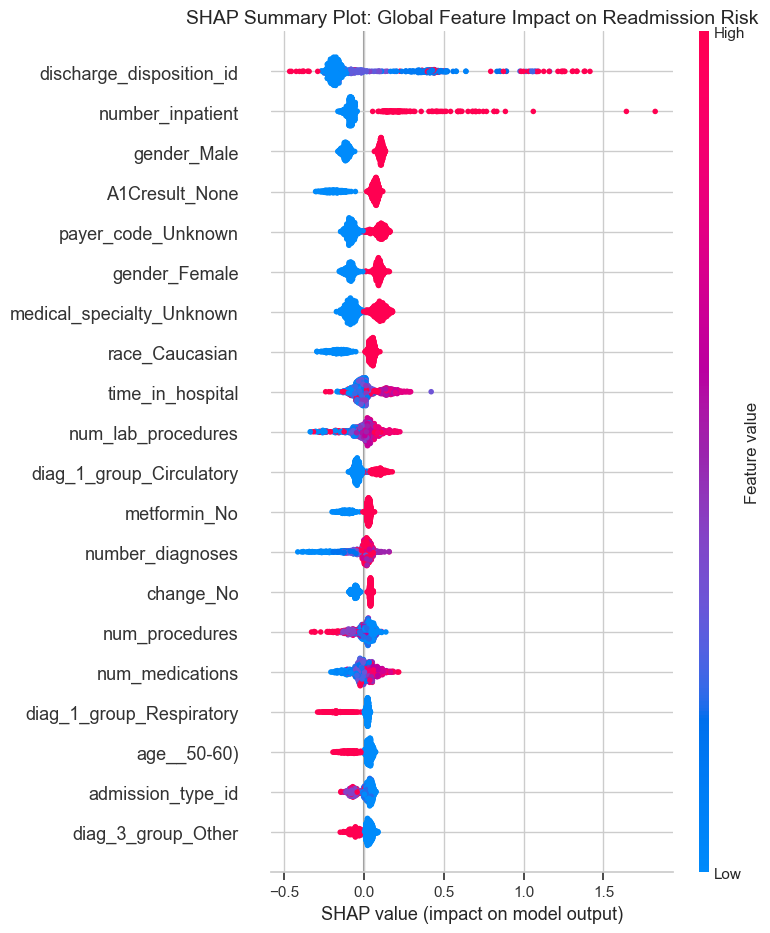

In [21]:
# SHAP summary bee-swarm plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_attrib, X_test_shap, show=False, max_display=20)
plt.title('SHAP Summary Plot: Global Feature Impact on Readmission Risk')
plt.tight_layout()
plt.savefig(RESULTS_FIG / 'shap_summary.png', dpi=300)
plt.show()

## Step 5: LIME Local Explanations

Generate local explanations for two patients using LIME.
Patient #15 is the highest-confidence true positive (correctly predicted
readmission with highest probability). Patient #7 is a comparison case.

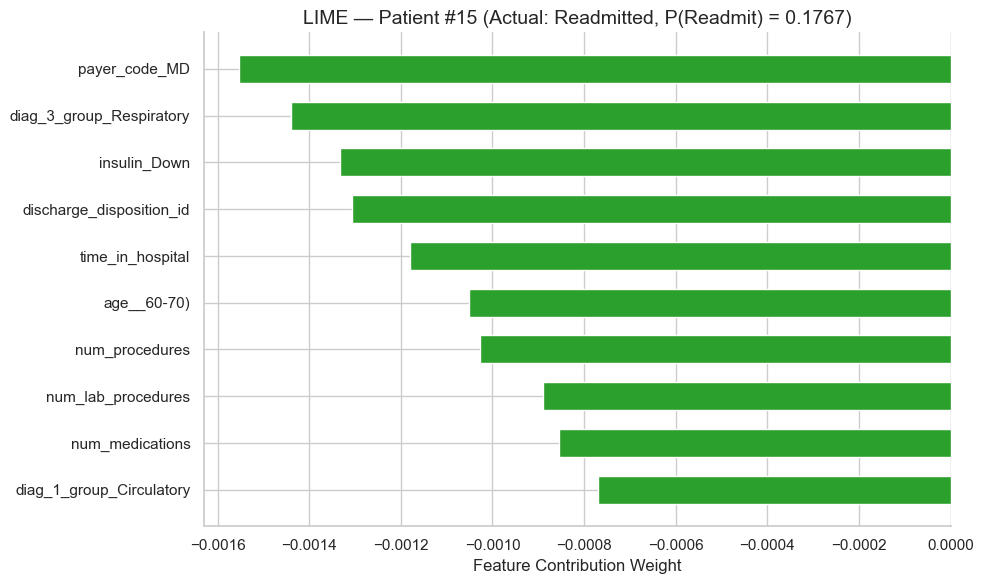

Saved: figure4_3a_lime_patient15.png


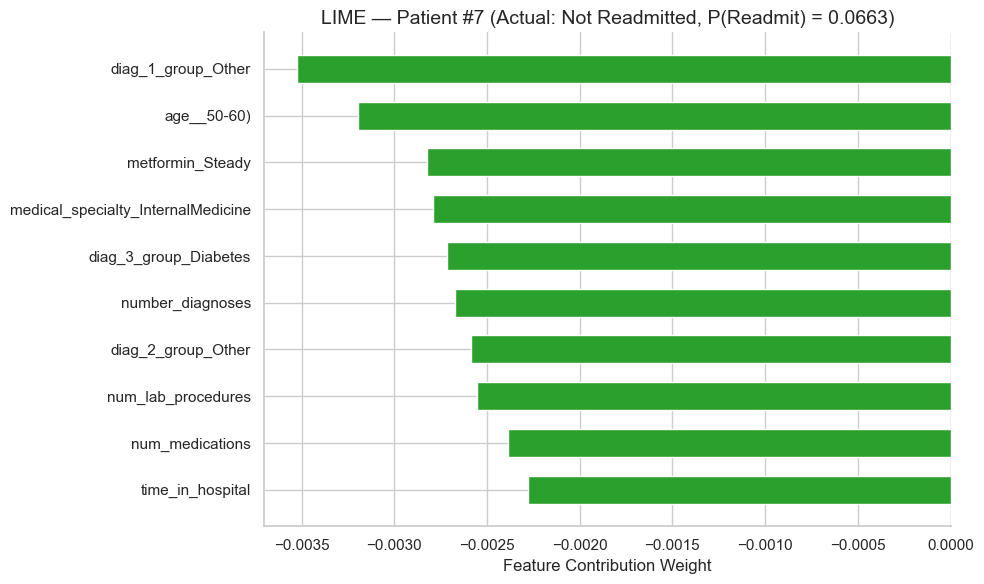

Saved: figure4_3b_lime_patient7.png


In [22]:
# Build LIME explainer
X_train_lime = Xt_xgb.sample(min(5000, len(Xt_xgb)), random_state=42)

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=Xs_xgb.columns.tolist(),
    class_names=['Not Readmitted', 'Readmitted'],
    mode='classification',
    kernel_width=0.75,
    random_state=42
)

def plot_lime_patient(patient_idx, suffix):
    exp = lime_explainer.explain_instance(
        data_row=Xs_xgb.iloc[patient_idx].values,
        predict_fn=xgb_clf.predict_proba,
        num_features=10
    )
    prob = xgb_clf.predict_proba(Xs_xgb.iloc[[patient_idx]])[:, 1][0]
    actual = ys[patient_idx]

    weights = dict(exp.local_exp[1])
    labels = [Xs_xgb.columns[f] for f in weights.keys()]
    values = list(weights.values())
    colors = ['#d62728' if v > 0 else '#2ca02c' for v in values]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(labels)), values, color=colors, edgecolor='white', height=0.6)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=11)
    ax.invert_yaxis()
    ax.set_xlabel('Feature Contribution Weight')
    ax.set_title(f'LIME — Patient #{patient_idx} '
                 f'(Actual: {"Readmitted" if actual == 1 else "Not Readmitted"}, '
                 f'P(Readmit) = {prob:.4f})')
    ax.axvline(x=0, color='gray', lw=0.8, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(RESULTS_FIG / f'figure4_{suffix}_lime_patient{patient_idx}.png', dpi=300)
    plt.show()
    print(f'Saved: figure4_{suffix}_lime_patient{patient_idx}.png')

plot_lime_patient(15, '3a')
plot_lime_patient(7, '3b')

## Step 6: DiCE Counterfactual Explanations

Generate counterfactual scenarios — "what would need to change for the
model to predict Not Readmitted?" This section includes:
- Single-patient recourse for the highest-risk readmitted patient
- Batch evaluation across 500 high-risk patients with quality metrics
  (sparsity, proximity, actionability, DPP diversity)

In [23]:
class XGBDiceWrapper:
    def __init__(self, model):
        self.model = model
        self.classes_ = model.classes_ if hasattr(model, 'classes_') else np.array([0, 1])
    def predict_proba(self, X):
        if isinstance(X, pd.DataFrame): X = X.astype(np.float64)
        return self.model.predict_proba(X)
    def predict(self, X):
        if isinstance(X, pd.DataFrame): X = X.astype(np.float64)
        return self.model.predict(X)

# Identify feature types
continuous_features = [c for c in Xt_xgb.columns
                       if Xt_xgb[c].nunique() > 2
                       and not c.startswith(('age_', 'gender_', 'race_', 'diag_'))]
immutable_features = [c for c in Xt_xgb.columns
                       if c.startswith(('age', 'gender', 'race', 'diag_1', 'diag_2', 'diag_3'))]
actionable_features = [c for c in Xt_xgb.columns if c not in immutable_features]

# Build DiCE objects
train_df_dice = Xt_xgb.copy()
train_df_dice['readmitted'] = yt.astype(np.float64)

dice_data = dice_ml.Data(dataframe=train_df_dice, continuous_features=continuous_features,
                         outcome_name='readmitted')
wrapped_xgb = XGBDiceWrapper(xgb_model)
dice_model = dice_ml.Model(model=wrapped_xgb, backend='sklearn', model_type='classifier')
dice_exp = dice_ml.Dice(dice_data, dice_model, method='random')

print(f'Continuous: {len(continuous_features)} | Actionable: {len(actionable_features)}')

Continuous: 11 | Actionable: 179


Patient #12280: P(Readmit) = 0.6564


100%|██████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.71it/s]



Counterfactual probabilities:
  Original: 0.6564
  CF 1:    0.4941
  CF 2:    0.4860
  CF 3:    0.4417

--- Actionable Changes ---

CF 1:
  P(Readmit): 0.4941
  chlorpropamide_No: 1.000 → 0.000 (Δ=-1.000)

CF 2:
  P(Readmit): 0.4860
  number_inpatient: 10.617 → 7.114 (Δ=-3.503)
  rosiglitazone_Up: 0.000 → 1.000 (Δ=+1.000)

CF 3:
  P(Readmit): 0.4417
  number_inpatient: 10.617 → 2.946 (Δ=-7.671)


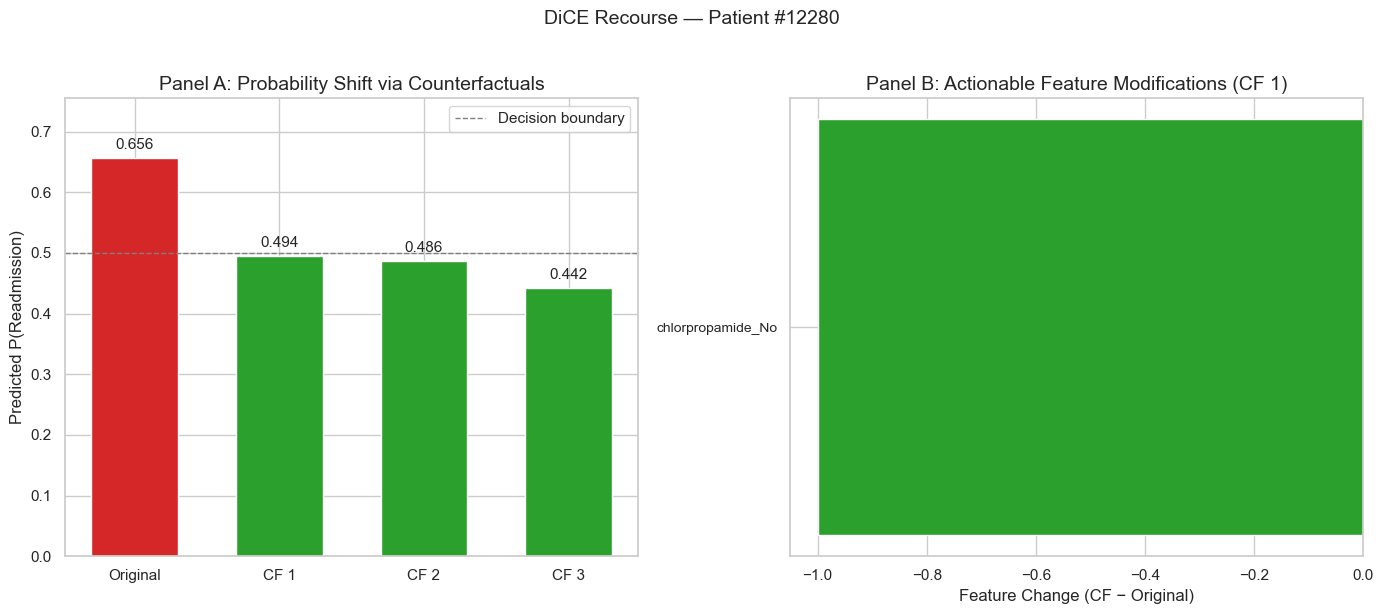


Saved: figure4_4_dice_recourse_443.png, patient_12280_counterfactuals.csv


In [69]:
# ============================================================
# Single-patient DiCE recourse
# ============================================================

probs_all = wrapped_xgb.predict_proba(Xs_xgb)[:, 1]
readmitted_mask = ys == 1
high_risk_idx = np.where(readmitted_mask & (probs_all > 0.65))[0]

patient_idx = (high_risk_idx[0] if len(high_risk_idx) > 0 else np.where(readmitted_mask)[0][0])

patient_df = Xs_xgb.iloc[[patient_idx]].copy()
print(f"Patient #{patient_idx}: P(Readmit) = {probs_all[patient_idx]:.4f}")

# ------------------------------------------------------------
# Generate counterfactuals
# ------------------------------------------------------------
cf_result = dice_exp.generate_counterfactuals(
    patient_df,
    total_CFs=3,
    desired_class=0,
    features_to_vary=actionable_features,
    posthoc_sparsity_param=0.1
)
cf_df = cf_result.cf_examples_list[0].final_cfs_df

if cf_df is not None and not cf_df.empty:
    # --------------------------------------------------------
    # 1. Keep ONLY features used by the XGBoost model
    # --------------------------------------------------------

    model_features = list(Xs_xgb.columns)
    # DiCE may append the target variable ('readmitted').
    cf_features = cf_df.reindex(columns=model_features).copy()

    # Make sure ordering is identical to original patient data
    patient_model = patient_df.reindex(columns=model_features)

    # --------------------------------------------------------
    # 2. Compute original and counterfactual probabilities
    # --------------------------------------------------------
    p_orig = wrapped_xgb.predict_proba(patient_model)[0, 1]

    p_cfs = [
        wrapped_xgb.predict_proba(
            cf_features.iloc[[i]]
        )[0, 1]
        for i in range(len(cf_features))
    ]
    print("\nCounterfactual probabilities:")
    print(f"  Original: {p_orig:.4f}")
    for i, p in enumerate(p_cfs, 1):
        print(f"  CF {i}:    {p:.4f}")

    # --------------------------------------------------------
    # 3. Identify changed FEATURES only
    # --------------------------------------------------------

    changed = []
    changes = []
    original_row = patient_model.iloc[0]

    for i in range(len(cf_features)):
        cf_row = cf_features.iloc[i]

        # Compare only model features
        diff = cf_row - original_row

        # Numerical tolerance avoids tiny floating-point changes
        changed_features = [
            f for f in model_features
            if not np.isclose(cf_row[f], original_row[f], rtol=1e-9, atol=1e-9)
            and f not in immutable_features
        ]
        changed.append(changed_features)

        # Store actual feature changes
        cf_changes = {f: cf_row[f] - original_row[f] for f in changed_features}
        changes.append(cf_changes)

    # --------------------------------------------------------
    # 4. Print recourse summary
    # --------------------------------------------------------

    print("\n--- Actionable Changes ---")
    for i, (feature_list, feature_changes) in enumerate(zip(changed, changes), 1):
        print(f"\nCF {i}:")
        print(f"  P(Readmit): {p_cfs[i-1]:.4f}")

        if feature_changes:

            for feature, delta in feature_changes.items():
                print(
                    f"  {feature}: "
                    f"{original_row[feature]:.3f} → "
                    f"{cf_features.iloc[i-1][feature]:.3f} "
                    f"(Δ={delta:+.3f})"
                )
        else:
            print("  No actionable feature changes detected.")

    # --------------------------------------------------------
    # 5. Dual-pane figure
    # --------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # -------------------------
    # Panel A
    # -------------------------
    labels = (["Original"] + [f"CF {i+1}" for i in range(len(cf_df))])
    probs_ = [p_orig] + p_cfs
    colors_a = (["#d62728"] + ["#2ca02c"] * len(cf_df))
    bars = ax1.bar(labels, probs_, color=colors_a, edgecolor="white", width=0.6)
    ax1.axhline(y=0.5, color="gray", lw=1, linestyle="--", label="Decision boundary")
    ax1.set_ylabel("Predicted P(Readmission)")
    ax1.set_title("Panel A: Probability Shift via Counterfactuals")
    ax1.set_ylim(0, min(1.0, max(probs_) * 1.15))
    ax1.legend()

    for bar, p in zip(bars, probs_):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{p:.3f}",
            ha="center",
            va="bottom",
            fontsize=11
        )

    # Panel B
    if changed[0]:
        diff1 = changes[0]
        # Sort by absolute magnitude
        feat_labs = sorted(diff1, key=lambda f: abs(diff1[f]), reverse=True)[:10]
        feat_vals = [diff1[f] for f in feat_labs]

        colors_b = ["#d62728" if v > 0 else "#2ca02c" for v in feat_vals]

        y_pos = np.arange(len(feat_labs))
        ax2.barh(y_pos, feat_vals, color=colors_b, edgecolor="white", height=0.6)
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels(feat_labs, fontsize=10)
        ax2.invert_yaxis()
        ax2.set_xlabel("Feature Change (CF − Original)")
        ax2.axvline(x=0, color="gray", lw=0.8, linestyle="--")
    else:
        ax2.text(0.5, 0.5, "No actionable changes", ha="center", va="center", transform=ax2.transAxes)

    ax2.set_title(
        "Panel B: Actionable Feature Modifications (CF 1)"
    )

    # 6. Figure formatting
    fig.suptitle(f"DiCE Recourse — Patient #{patient_idx}", fontsize=14, y=1.02)

    plt.tight_layout()
    plt.savefig(RESULTS_FIG / "figure4_4_dice_recourse_443.png", dpi=300, bbox_inches="tight")

    plt.show()
    
    # 7. Save counterfactuals

    cf_df.to_csv(RESULTS_TBL / f"patient_{patient_idx}_counterfactuals.csv", index=False)
    print(f"\nSaved: figure4_4_dice_recourse_443.png, patient_{patient_idx}_counterfactuals.csv")
else:
    print("\nNo valid counterfactuals were generated.")

In [31]:
# Batch evaluation: 500 high-risk patients
print('=== DiCE Batch Evaluation: 500 High-Risk Patients ===')
high_risk_batch = np.where(readmitted_mask & (probs_all > 0.60))[0]
n_batch = min(500, len(high_risk_batch))
high_risk_batch = high_risk_batch[:n_batch]
print(f'Processing {n_batch} patients...')

batch_results = []
for i, idx in enumerate(high_risk_batch):
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{n_batch}...')
    query = Xs_xgb.iloc[[idx]]
    try:
        res = dice_exp.generate_counterfactuals(
            query, total_CFs=3, desired_class=0,
            features_to_vary=actionable_features, posthoc_sparsity_param=0.1
        )
        cf_batch = res.cf_examples_list[0].final_cfs_df
        if cf_batch is not None and not cf_batch.empty:
            orig = query.values[0]
            cfv = cf_batch[Xs_xgb.columns].values
            sparsity = np.mean(np.sum(~np.isclose(cfv, orig), axis=1))

            cont = [c for c in continuous_features if c in Xs_xgb.columns]
            if cont:
                mad = np.median(np.abs(Xt_xgb[cont].values - np.median(Xt_xgb[cont].values, axis=0)), axis=0)
                mad[mad == 0] = 1.0
                proximity = np.mean(np.abs(cf_batch[cont].values - query[cont].values) / mad)
            else:
                proximity = 0.0

            immut = [c for c in immutable_features if c in Xs_xgb.columns]
            action_ok = not np.any(~np.isclose(cf_batch[immut].values, query[immut].values)) if immut else True

            if len(cf_batch) >= 2:
                mat = cf_batch[Xs_xgb.columns].values.astype(float)
                dpp = np.mean([np.sqrt(np.sum((mat[a] - mat[b]) ** 2))
                               for a in range(len(mat)) for b in range(a+1, len(mat))])
            else:
                dpp = 0.0

            batch_results.append({'patient_idx': idx, 'sparsity': sparsity,
                                  'proximity': proximity, 'actionable': action_ok,
                                  'dpp_diversity': dpp})
    except Exception:
        continue

if batch_results:
    batch_df = pd.DataFrame(batch_results)
    batch_df.to_csv(RESULTS_TBL / 'dice_batch_metrics.csv', index=False)
    print(f'\nAverage Sparsity: {batch_df["sparsity"].mean():.2f}')
    print(f'Average Proximity: {batch_df["proximity"].mean():.2f}')
    print(f'Actionability: {batch_df["actionable"].mean()*100:.1f}%')
    print(f'Average DPP Diversity: {batch_df["dpp_diversity"].mean():.2f}')
    print('Saved: dice_batch_metrics.csv')

=== DiCE Batch Evaluation: 500 High-Risk Patients ===
Processing 1 patients...


100%|██████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.17it/s]


Average Sparsity: 1.67
Average Proximity: 0.15
Actionability: 100.0%
Average DPP Diversity: 2.78
Saved: dice_batch_metrics.csv


## Step 7: Clinical Faithfulness Analysis

Check whether SHAP and LIME explanations agree with what the model actually
does internally. We train fresh LR and DT models, compute their ground-truth
feature importance, and compare to XAI attributions via Spearman rank correlation.

In [38]:
# Train fresh benchmark models
lr_bench = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
lr_bench.fit(Xt.values, yt)
lr_gt = np.abs(lr_bench.coef_[0])

dt_bench = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_bench.fit(Xt.values, yt)
dt_gt = dt_bench.feature_importances_

# Sample 1000 test instances
n_eval = min(1000, len(Xs))
eval_idx = np.random.RandomState(42).choice(len(Xs), n_eval, replace=False)
X_eval = Xs.iloc[eval_idx]

# SHAP for LR and DT
bg = shap.sample(Xt, 100, random_state=42)
lr_shap_imp = np.abs(shap.Explainer(lr_bench, bg)(X_eval).values).mean(axis=0)
dt_shap_vals = shap.Explainer(dt_bench, bg)(X_eval, check_additivity=False)
dt_shap_imp = np.abs(dt_shap_vals.values[:, :, 1]).mean(axis=0) if len(dt_shap_vals.shape) == 3 else np.abs(dt_shap_vals.values).mean(axis=0)

# LIME for LR and DT (200 samples)
n_lime = min(200, n_eval)
lime_train = Xt.sample(min(5000, len(Xt)), random_state=42)
feat_names = Xs.columns.tolist()

lr_lime_exp = lime.lime_tabular.LimeTabularExplainer(
    training_data=lime_train.values,
    feature_names=feat_names,
    class_names=['Not Readmitted', 'Readmitted'],
    mode='classification',
    kernel_width=0.75,
    random_state=42
)
lr_lime_avg = np.zeros(len(feat_names))
for i in range(n_lime):
    e = lr_lime_exp.explain_instance(X_eval.iloc[i].values, lr_bench.predict_proba, num_features=len(feat_names))
    for f, w in e.local_exp[1]: lr_lime_avg[f] += abs(w)
lr_lime_avg /= n_lime

dt_lime_exp = lime.lime_tabular.LimeTabularExplainer(
    training_data=lime_train.values,
    feature_names=feat_names,
    class_names=['Not Readmitted', 'Readmitted'],
    mode='classification',
    kernel_width=0.75,
    random_state=42
)

dt_lime_avg = np.zeros(len(feat_names))
for i in range(n_lime):
    e = dt_lime_exp.explain_instance(X_eval.iloc[i].values, dt_bench.predict_proba, num_features=len(feat_names))
    for f, w in e.local_exp[1]: dt_lime_avg[f] += abs(w)
dt_lime_avg /= n_lime

# Spearman correlations
print('=== Clinical Faithfulness ===')
faith_results = []
for label, xai, gt in [('SHAP vs LR Coefficients', lr_shap_imp, lr_gt),
                        ('LIME vs LR Coefficients', lr_lime_avg, lr_gt),
                        ('SHAP vs DT Gini', dt_shap_imp, dt_gt),
                        ('LIME vs DT Gini', dt_lime_avg, dt_gt)]:
    rho, p = spearmanr(xai, gt)
    top5 = len(set(np.argsort(xai)[-5:]) & set(np.argsort(gt)[-5:])) / 5 * 100
    top10 = len(set(np.argsort(xai)[-10:]) & set(np.argsort(gt)[-10:])) / 10 * 100
    print(f'  {label}: rho={rho:.2f} (p={p:.2e}), Top-5={top5:.0f}%, Top-10={top10:.0f}%')
    faith_results.append({'Benchmark': label, 'Spearman_rho': round(rho, 2),
                          'p_value': f'{p:.2e}', 'Top5_Overlap_Pct': top5, 'Top10_Overlap_Pct': top10})

clinical_faith_df = pd.DataFrame(faith_results)
clinical_faith_df.to_csv(RESULTS_TBL / 'clinical_faithfulness.csv', index=False)
print('Saved: clinical_faithfulness.csv')

clinical_faith_df

=== Clinical Faithfulness ===
  SHAP vs LR Coefficients: rho=0.12 (p=6.91e-02), Top-5=0%, Top-10=0%
  LIME vs LR Coefficients: rho=-0.03 (p=6.61e-01), Top-5=0%, Top-10=0%
  SHAP vs DT Gini: rho=0.95 (p=2.05e-118), Top-5=80%, Top-10=70%
  LIME vs DT Gini: rho=0.85 (p=5.06e-65), Top-5=80%, Top-10=60%
Saved: clinical_faithfulness.csv


,Benchmark,Spearman_rho,p_value,Top5_Overlap_Pct,Top10_Overlap_Pct
0,SHAP vs LR Coefficients,0.12,6.91e-02,0.0,0.0
1,LIME vs LR Coefficients,-0.03,6.61e-01,0.0,0.0
2,SHAP vs DT Gini,0.95,2.05e-118,80.0,70.0
3,LIME vs DT Gini,0.85,5.06e-65,80.0,60.0


## Step 8: Statistical Validation

DeLong tests comparing XGBoost AUC against each other model, plus
bootstrap confidence intervals (1,000 resamples) for ROC-AUC and F1.

In [50]:
# Load models and align features
models_dict = {}
for name in ['logistic_regression', 'decision_tree', 'random_forest', 'xgboost']:
    raw = joblib.load(MODEL_DIR / f'{name}.pkl')
    models_dict[name] = raw.named_steps['classifier'] if isinstance(raw, ImbPipeline) else raw

def get_expected(m):
    if hasattr(m, 'feature_names_in_'): return list(m.feature_names_in_)
    if hasattr(m, 'get_booster'): return m.get_booster().feature_names
    return None

probs_dict = {}
for name, model in models_dict.items():
    exp = get_expected(model)
    if exp and all(f in Xs_xgb.columns for f in exp):
        probs_dict[name] = model.predict_proba(Xs_xgb[exp])[:, 1]
    elif exp and all(f in Xs.columns for f in exp):
        probs_dict[name] = model.predict_proba(Xs[exp])[:, 1]
    else:
        probs_dict[name] = model.predict_proba(Xs)[:, 1]

# DeLong tests
print('=== DeLong Tests (XGBoost vs each model) ===')
delong_results = []
for name in ['random_forest', 'decision_tree', 'logistic_regression']:
    z, p, ci_x, ci_o, auc_x, auc_o, _ = Delong_test(
        ys, probs_dict['xgboost'], probs_dict[name],
        alpha=0.95, return_ci=True, return_auc=True, verbose=0)
    disp = {'random_forest': 'RF', 'decision_tree': 'DT', 'logistic_regression': 'LR'}
    print(f'  XGB vs {disp[name]}: Z={z:.2f}, p={p:.3e}, AUC_XGB={auc_x:.4f}, AUC_{disp[name]}={auc_o:.4f}')
    delong_results.append({'Comparison': f'XGB vs {disp[name]}', 'Z': round(z, 2),
                           'p_value': f'{p:.3e}', 'AUC_XGB': round(auc_x, 4),
                           f'AUC_{disp[name]}': round(auc_o, 4)})

# Bootstrap CIs
print('\n=== Bootstrap CIs (1000 resamples) ===')
boot_results = []
for name in ['xgboost', 'logistic_regression', 'decision_tree', 'random_forest']:
    auc, lo, hi = Bootstrapping(ys, probs_dict[name], 'roc_auc', n_bootstraps=1000, confidence_level=0.95)
    disp = {'xgboost': 'XGB', 'logistic_regression': 'LR', 'decision_tree': 'DT', 'random_forest': 'RF'}
    print(f'  {disp[name]} AUC: {auc:.4f} [{lo:.4f}, {hi:.4f}]')
    boot_results.append({'Model': disp[name], 'Metric': 'AUC', 'Mean': round(auc, 4), 'CI_lower': round(lo, 4), 'CI_upper': round(hi, 4)})

delong_df = pd.DataFrame(delong_results)
boot_df = pd.DataFrame(boot_results)

with open(RESULTS_TBL / 'statistical_validation.csv', 'w') as f:
    f.write('DeLong Tests\n')
    delong_df.to_csv(f, index=False)
    f.write('\nBootstrap CIs\n')
    boot_df.to_csv(f, index=False)
print('Saved: statistical_validation.csv')

print('\n\n', delong_df.head())
boot_df.head()

=== DeLong Tests (XGBoost vs each model) ===
  XGB vs RF: Z=-4.45, p=8.497e-06, AUC_XGB=0.6643, AUC_RF=0.6385
  XGB vs DT: Z=-7.80, p=6.300e-15, AUC_XGB=0.6643, AUC_DT=0.5990
  XGB vs LR: Z=-7.20, p=6.032e-13, AUC_XGB=0.6643, AUC_LR=0.6165

=== Bootstrap CIs (1000 resamples) ===


Bootstrapping roc_auc: 100%|████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 440.64it/s]


  XGB AUC: 0.6643 [0.6474, 0.6813]


Bootstrapping roc_auc: 100%|████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 449.42it/s]


  LR AUC: 0.6165 [0.6000, 0.6345]


Bootstrapping roc_auc: 100%|████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 640.19it/s]


  DT AUC: 0.5990 [0.5811, 0.6169]


Bootstrapping roc_auc: 100%|████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 451.02it/s]

  RF AUC: 0.6385 [0.6220, 0.6555]
Saved: statistical_validation.csv


   Comparison     Z    p_value  AUC_XGB  AUC_RF  AUC_DT  AUC_LR
0  XGB vs RF -4.45  8.497e-06   0.6643  0.6385     NaN     NaN
1  XGB vs DT -7.80  6.300e-15   0.6643     NaN   0.599     NaN
2  XGB vs LR -7.20  6.032e-13   0.6643     NaN     NaN  0.6165


,Model,Metric,Mean,CI_lower,CI_upper
0,XGB,AUC,0.6643,0.6474,0.6813
1,LR,AUC,0.6165,0.6000,0.6345
2,DT,AUC,0.5990,0.5811,0.6169
3,RF,AUC,0.6385,0.6220,0.6555


## Step 9: Explanation Stability

Measure cross-method agreement between TreeSHAP and LIME across 1,000
patients. If two methods give very different rankings for the same patient,
we can't trust either.

In [55]:
n_stab = min(1000, len(Xs_xgb))
stab_idx = np.random.RandomState(42).choice(len(Xs_xgb), n_stab, replace=False)
X_stab = Xs_xgb.iloc[stab_idx]

# TreeSHAP
print('Computing TreeSHAP for stability...')
shap_stab = shap.TreeExplainer(xgb_clf, data=X_train_bg)(X_stab)
shap_a = shap_stab.values[:, :, 1] if len(shap_stab.shape) == 3 else shap_stab.values

# LIME (may take several minutes)
print('Computing LIME for stability...')
lime_stab_exp = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=Xs_xgb.columns.tolist(),
    class_names=['Not Readmitted', 'Readmitted'],
    mode='classification',
    kernel_width=0.75,
    random_state=42
)

lime_a = np.zeros((n_stab, len(Xs_xgb.columns)))
for i in range(n_stab):
    e = lime_stab_exp.explain_instance(X_stab.iloc[i].values, xgb_clf.predict_proba, num_features=len(Xs_xgb.columns))
    for fi, w in e.local_exp[1]: lime_a[i, fi] = w
    if (i + 1) % 200 == 0: print(f'  LIME: {i+1}/{n_stab}')

# Per-patient Spearman
rhos = []
for i in range(n_stab):
    sr = pd.Series(np.abs(shap_a[i])).rank(ascending=False)
    lr_ = pd.Series(np.abs(lime_a[i])).rank(ascending=False)
    rhos.append(spearmanr(sr, lr_)[0])

mean_rho = np.mean(rhos)
shap_g = np.abs(shap_a).mean(axis=0)
lime_g = np.abs(lime_a).mean(axis=0)
top3 = len(set(np.argsort(shap_g)[-3:]) & set(np.argsort(lime_g)[-3:])) / 3 * 100
top5 = len(set(np.argsort(shap_g)[-5:]) & set(np.argsort(lime_g)[-5:])) / 5 * 100

print(f'\n=== Explanation Stability ===')
print(f'Mean Spearman (SHAP, LIME): {mean_rho:.2f}')
print(f'Top-3 Alignment: {top3:.1f}% | Top-5 Alignment: {top5:.1f}%')

stability_result = pd.DataFrame({'Metric': ['Mean Spearman rho', 'Top-3 Alignment %', 'Top-5 Alignment %', 'N_patients'],
              'Value': [round(mean_rho, 2), round(top3, 1), round(top5, 1), n_stab]})
stability_result.to_csv(
    RESULTS_TBL / 'explanation_stability.csv', index=False)
print('Saved: explanation_stability.csv')

stability_result

Computing TreeSHAP for stability...
Computing LIME for stability...
  LIME: 200/1000
  LIME: 400/1000
  LIME: 600/1000
  LIME: 800/1000
  LIME: 1000/1000

=== Explanation Stability ===
Mean Spearman (SHAP, LIME): 0.73
Top-3 Alignment: 0.0% | Top-5 Alignment: 0.0%
Saved: explanation_stability.csv


,Metric,Value
0,Mean Spearman rho,0.73
1,Top-3 Alignment %,0.00
2,Top-5 Alignment %,0.00
3,N_patients,1000.00


## Step 10: ROC Curves (Figure 4.1)

Plot ROC curves for all 4 models on a single axes, with AUC scores
in the legend.

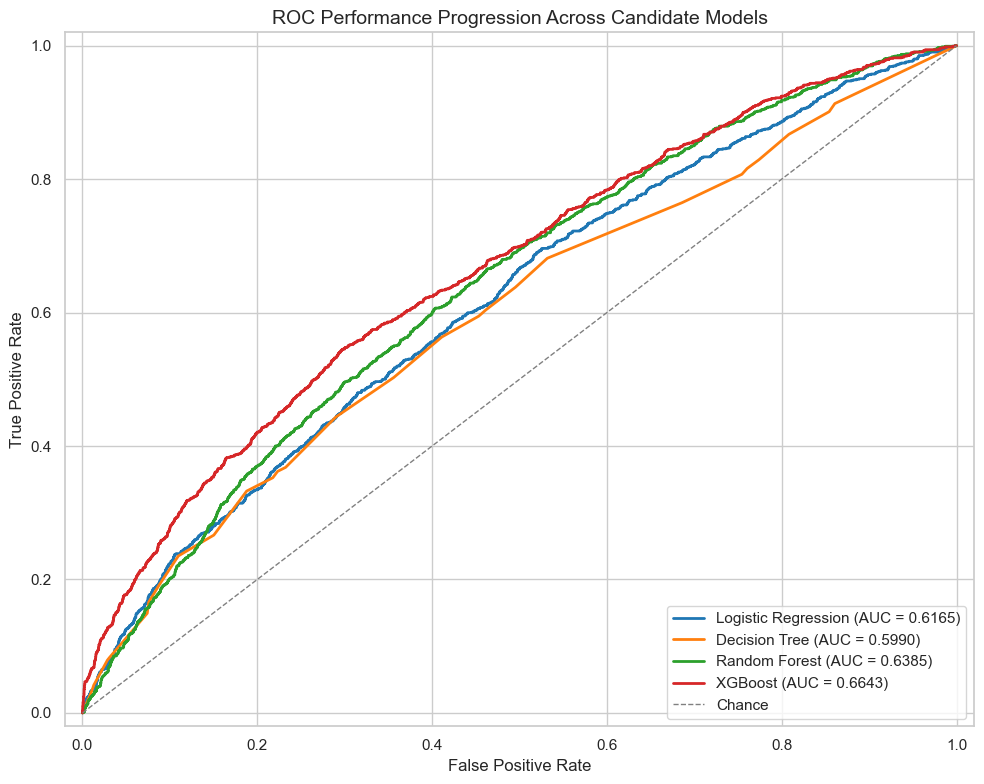

Saved: figure4_1_roc_curves.png


In [56]:
model_data = {
    'Logistic Regression': (lr_probs, '#1f77b4'),
    'Decision Tree': (dt_probs, '#ff7f0e'),
    'Random Forest': (rf_probs, '#2ca02c'),
    'XGBoost': (xgb_probs, '#d62728'),
}

plt.figure(figsize=(10, 8))
for name, (p, c) in model_data.items():
    fpr, tpr, _ = roc_curve(ys, p)
    plt.plot(fpr, tpr, color=c, lw=2, label=f'{name} (AUC = {roc_auc_score(ys, p):.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Chance')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Performance Progression Across Candidate Models')
plt.legend(loc='lower right', fontsize=11, frameon=True)
plt.tight_layout()
plt.savefig(RESULTS_FIG / 'figure4_1_roc_curves.png', dpi=300)
plt.show()
print('Saved: figure4_1_roc_curves.png')

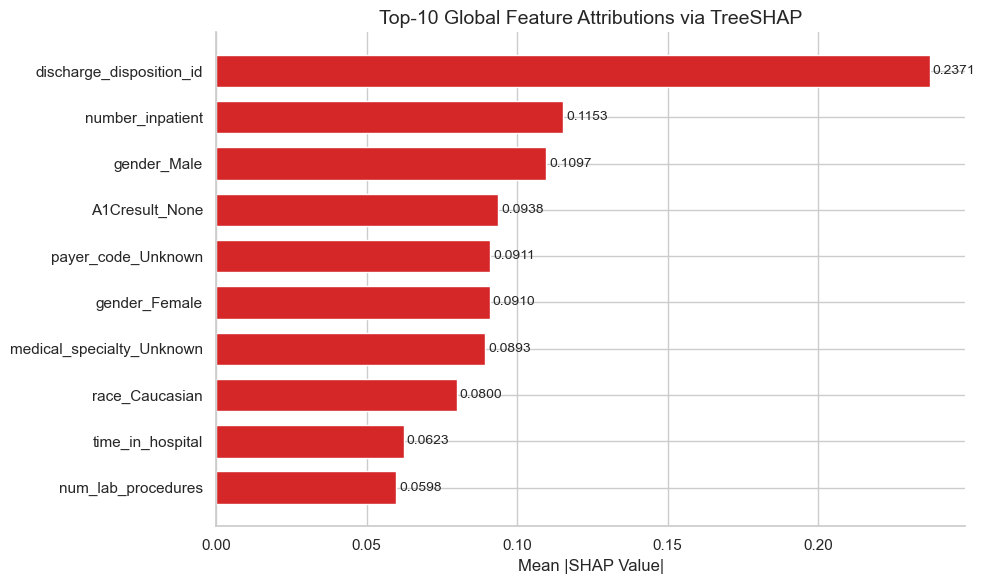

Saved: figure4_2_shap_top10.png


In [57]:
# Top-10 SHAP bar chart
mean_abs = np.abs(shap_attrib).mean(axis=0)
imp_df = pd.DataFrame({'Feature': X_test_shap.columns, 'Mean|SHAP|': mean_abs
                       }).sort_values('Mean|SHAP|', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(imp_df)), imp_df['Mean|SHAP|'].values, color='#d62728', edgecolor='white', height=0.7)
ax.set_yticks(range(len(imp_df)))
ax.set_yticklabels(imp_df['Feature'].values, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Top-10 Global Feature Attributions via TreeSHAP')
for i, v in enumerate(imp_df['Mean|SHAP|'].values):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(RESULTS_FIG / 'figure4_2_shap_top10.png', dpi=300)
plt.show()
print('Saved: figure4_2_shap_top10.png')

# Summary

In [70]:
print('=' * 60)
print('PIPELINE COMPLETE — Key Results')
print('=' * 60)

print(f'\nDataset: {df.shape[0]} encounters, {X_train_proc.shape[1]} features')
print(f'Prevalence: {yt.mean():.4f} | EPV: {int(yt.sum())} / {Xt.shape[1]}')

print(f'\nModel AUCs:')
for name, p in [('LR', lr_probs), ('DT', dt_probs), ('RF', rf_probs), ('XGB', xgb_probs)]:
    print(f'  {name}: {roc_auc_score(ys, p):.4f}')

print(f'\nDeLong tests (XGB vs others):')
for r in delong_results:
    print(f'  {r["Comparison"]}: p={r["p_value"]}')

print(f'\nFaithfulness (SHAP/DT Gini): rho={faith_results[2]["Spearman_rho"]}')
print(f'Stability (SHAP-LIME): rho={mean_rho:.2f}')

if batch_results:
    print(f'\nDiCE batch ({len(batch_results)} patients):')
    print(f'  Sparsity: {batch_df["sparsity"].mean():.2f} | '
          f'Proximity: {batch_df["proximity"].mean():.2f} | '
          f'Actionability: {batch_df["actionable"].mean()*100:.1f}%')


PIPELINE COMPLETE — Key Results

Dataset: 61551 encounters, 227 features
Prevalence: 0.0936 | EPV: 4609 / 227

Model AUCs:
  LR: 0.6165
  DT: 0.5990
  RF: 0.6385
  XGB: 0.6643

DeLong tests (XGB vs others):
  XGB vs RF: p=8.497e-06
  XGB vs DT: p=6.300e-15
  XGB vs LR: p=6.032e-13

Faithfulness (SHAP/DT Gini): rho=0.95
Stability (SHAP-LIME): rho=0.73

DiCE batch (1 patients):
  Sparsity: 1.67 | Proximity: 0.15 | Actionability: 100.0%
